<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/05_Matrices%2CPart_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 5: Matrix Rank

**Referensi:** Practical Linear Algebra for Data Science (O'Reilly) - Mike X Cohen

---

## Ringkasan Bab

Bab ini membahas konsep **rank** sebuah matriks, yaitu jumlah dimensi independen yang terdapat dalam ruang kolom atau ruang baris matriks tersebut. Rank adalah salah satu properti matriks yang paling penting dalam aljabar linear dan machine learning karena menentukan apakah suatu sistem persamaan linear memiliki solusi unik, tidak ada solusi, atau solusi tak terhingga.

Topik utama yang dibahas:
- Definisi dan konsep rank matriks
- Rank matriks vektor dan matriks hasil perkalian
- Full rank vs rank-deficient matrix
- Cara menghitung rank secara komputasi
- Reduced row echelon form (RREF)
- Hubungan rank dengan pivot
- Rank dalam konteks machine learning

## 5.1 Apa Itu Rank?

**Rank** dari sebuah matriks adalah jumlah kolom (atau baris) yang **linearly independent** di dalam matriks tersebut. Secara intuitif, rank mengukur berapa banyak "informasi unik" yang terkandung dalam matriks.

Notasi: rank(A) atau r(A)

Properti penting:
- rank(A) selalu merupakan bilangan bulat non-negatif
- rank(A) <= min(m, n) untuk matriks berukuran m x n
- rank(A) = rank(A^T)
- Jika rank(A) = min(m, n), maka A disebut **full rank**
- Jika rank(A) < min(m, n), maka A disebut **rank-deficient** atau **singular**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## 5.2 Rank dari Vektor

Sebelum membahas rank matriks secara umum, perlu dipahami rank dari vektor:
- Vektor nol memiliki rank = 0
- Vektor bukan-nol memiliki rank = 1

Matriks yang dibentuk dari outer product dua vektor (v * w^T) selalu memiliki rank 1, karena semua kolomnya adalah kelipatan dari satu vektor.

In [2]:
# rank dari vektor
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7])

# Outer product menghasilkan matriks rank-1
A = np.outer(v, w)
print('Matrix A (outer product):')
print(A)
print()
print('Rank of A:', np.linalg.matrix_rank(A))

Matrix A (outer product):
[[ 5  6  7]
 [10 12 14]
 [15 18 21]
 [20 24 28]]

Rank of A: 1


In [3]:
# Verifikasi: semua kolom A adalah kelipatan dari kolom pertama
print('Kolom pertama A:', A[:, 0])
print('Kolom kedua A:', A[:, 1])
print('Rasio kolom 2 / kolom 1:', A[:, 1] / A[:, 0])
# Rasio konstan membuktikan kolom-kolom tersebut linearly dependent

Kolom pertama A: [ 5 10 15 20]
Kolom kedua A: [ 6 12 18 24]
Rasio kolom 2 / kolom 1: [1.2 1.2 1.2 1.2]


## 5.3 Rank Matriks Secara Umum

Untuk menghitung rank, kita bisa menggunakan pendekatan berikut:
1. Eliminasi Gauss (row reduction) untuk menemukan jumlah pivot
2. SVD (Singular Value Decomposition): rank = jumlah singular value yang non-nol
3. Fungsi bawaan NumPy: `np.linalg.matrix_rank()`

**Full rank matrix:**
- Matriks persegi n x n dengan rank n disebut **full rank** atau **non-singular** atau **invertible**
- Matriks rectangular m x n disebut full rank jika rank = min(m, n)

In [4]:
# Contoh matriks full rank
A_full = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 0]   # baris ketiga tidak linear dengan baris lainnya
])

print('Matrix A_full:')
print(A_full)
print('Rank:', np.linalg.matrix_rank(A_full))
print('Expected rank (full rank):', min(A_full.shape))

Matrix A_full:
[[1 2 3]
 [4 5 6]
 [7 8 0]]
Rank: 3
Expected rank (full rank): 3


In [5]:
# Contoh matriks rank-deficient
A_def = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]   # baris ketiga = baris kedua + baris pertama (linearly dependent)
])

print('Matrix A_def:')
print(A_def)
print('Rank:', np.linalg.matrix_rank(A_def))
print()
print('Baris ke-3 = 2 * baris ke-2 - baris ke-1?',
      np.allclose(A_def[2], 2*A_def[1] - A_def[0]))

Matrix A_def:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Rank: 2

Baris ke-3 = 2 * baris ke-2 - baris ke-1? True


## 5.4 Rank Matriks Acak

Matriks yang di-generate secara acak dengan nilai kontinu hampir pasti akan memiliki full rank. Ini karena kemungkinan dua kolom atau baris yang di-generate secara independen menjadi linearly dependent adalah nol (secara probabilistik).

Namun, jika kita memaksa salah satu kolom menjadi kombinasi linear dari kolom lain, rank akan berkurang.

In [6]:
# Matriks acak hampir selalu full rank
np.random.seed(0)
R = np.random.randn(4, 4)
print('Matriks acak 4x4:')
print(np.round(R, 2))
print('Rank:', np.linalg.matrix_rank(R))

Matriks acak 4x4:
[[ 1.76  0.4   0.98  2.24]
 [ 1.87 -0.98  0.95 -0.15]
 [-0.1   0.41  0.14  1.45]
 [ 0.76  0.12  0.44  0.33]]
Rank: 4


In [7]:
# Paksa kolom terakhir menjadi kombinasi linear kolom lainnya
R_def = R.copy()
R_def[:, 3] = R_def[:, 0] + 2 * R_def[:, 1]  # kolom 4 = kolom 1 + 2*kolom 2

print('Matriks dengan kolom ke-4 yang linear dependent:')
print(np.round(R_def, 2))
print('Rank:', np.linalg.matrix_rank(R_def))

Matriks dengan kolom ke-4 yang linear dependent:
[[ 1.76  0.4   0.98  2.56]
 [ 1.87 -0.98  0.95 -0.09]
 [-0.1   0.41  0.14  0.72]
 [ 0.76  0.12  0.44  1.  ]]
Rank: 3


## 5.5 Rank dan Reduced Row Echelon Form (RREF)

**RREF** adalah bentuk standar dari matriks yang diperoleh melalui proses **eliminasi Gauss-Jordan**. Dalam RREF:
- Setiap baris non-nol memiliki elemen leading (pivot) bernilai 1
- Setiap kolom pivot hanya memiliki satu elemen non-nol
- Baris-baris nol berada di bagian bawah
- Pivot baris bawah berada lebih ke kanan dari pivot baris atas

Jumlah pivot dalam RREF sama dengan rank matriks.

In [8]:
# NumPy tidak punya fungsi RREF bawaan, kita buat manual atau pakai sympy
from sympy import Matrix

A_sym = Matrix([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

rref_result, pivot_cols = A_sym.rref()
print('Matrix awal:')
print(A_sym)
print()
print('RREF:')
print(rref_result)
print()
print('Kolom pivot:', pivot_cols)
print('Rank (= jumlah pivot):', len(pivot_cols))

Matrix awal:
Matrix([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])

RREF:
Matrix([[1, 0, -1, -2], [0, 1, 2, 3], [0, 0, 0, 0]])

Kolom pivot: (0, 1)
Rank (= jumlah pivot): 2


In [9]:
# RREF dari matriks full rank
B_sym = Matrix([
    [1, 2, 0],
    [0, 1, 3],
    [4, 0, 1]
])

rref_B, pivots_B = B_sym.rref()
print('Matrix B awal:')
print(B_sym)
print()
print('RREF dari B:')
print(rref_B)
print('Kolom pivot:', pivots_B)
print('Rank:', len(pivots_B))

Matrix B awal:
Matrix([[1, 2, 0], [0, 1, 3], [4, 0, 1]])

RREF dari B:
Matrix([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
Kolom pivot: (0, 1, 2)
Rank: 3


## 5.6 Rank Matriks Rectangular

Untuk matriks rectangular m x n:
- **Full column rank**: rank = n (semua kolom independen). Berlaku jika m >= n
- **Full row rank**: rank = m (semua baris independen). Berlaku jika m <= n

Rank matriks rectangular penting dalam konteks regresi linear dan least-squares.

In [10]:
# Matriks tall (more rows than columns) - bisa full column rank
T = np.array([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
])
print('Tall matrix T (4x2):')
print(T)
print('Shape:', T.shape)
print('Rank:', np.linalg.matrix_rank(T))
print('Full column rank?', np.linalg.matrix_rank(T) == T.shape[1])

Tall matrix T (4x2):
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Shape: (4, 2)
Rank: 2
Full column rank? True


In [11]:
# Matriks wide (more columns than rows) - bisa full row rank
W = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8]
])
print('Wide matrix W (2x4):')
print(W)
print('Shape:', W.shape)
print('Rank:', np.linalg.matrix_rank(W))
print('Full row rank?', np.linalg.matrix_rank(W) == W.shape[0])

Wide matrix W (2x4):
[[1 2 3 4]
 [5 6 7 8]]
Shape: (2, 4)
Rank: 2
Full row rank? True


## 5.7 Rank dan Perkalian Matriks

Rank memiliki sifat yang menarik terkait perkalian matriks:

- **rank(AB) <= min(rank(A), rank(B))**
- Perkalian matriks tidak bisa meningkatkan rank
- Jika A adalah matriks n x n yang full rank (invertible), maka: rank(AB) = rank(B) dan rank(BA) = rank(B)

Ini berarti perkalian dengan matriks full rank tidak mengubah rank.

In [12]:
# Demonstrasi rank dari perkalian matriks
np.random.seed(42)

# Buat matriks rank-2 dari outer products
a1, b1 = np.random.randn(4), np.random.randn(3)
a2, b2 = np.random.randn(4), np.random.randn(3)

A = np.outer(a1, b1) + np.outer(a2, b2)  # rank-2 matrix

print('Rank of A (harus 2):', np.linalg.matrix_rank(A))

# Perkalian dengan matriks full rank tidak mengubah rank
F = np.random.randn(3, 3)  # full rank square matrix
print('Rank of F:', np.linalg.matrix_rank(F))
print('Rank of A @ F:', np.linalg.matrix_rank(A @ F))

Rank of A (harus 2): 2
Rank of F: 3
Rank of A @ F: 2


In [13]:
# Rank tidak bisa meningkat melalui perkalian
A_r2 = np.random.randn(4, 2) @ np.random.randn(2, 5)  # konstruksi matriks rank-2
B_rand = np.random.randn(5, 3)

print('Rank of A_r2 (4x5):', np.linalg.matrix_rank(A_r2))
print('Rank of B_rand (5x3):', np.linalg.matrix_rank(B_rand))
print('Rank of A_r2 @ B_rand:', np.linalg.matrix_rank(A_r2 @ B_rand))
print('max possible rank: min(rank(A), rank(B)) =', min(
    np.linalg.matrix_rank(A_r2), np.linalg.matrix_rank(B_rand)))

Rank of A_r2 (4x5): 2
Rank of B_rand (5x3): 3
Rank of A_r2 @ B_rand: 2
max possible rank: min(rank(A), rank(B)) = 2


## 5.8 Rank dan Determinan

Untuk matriks persegi:
- Jika rank = n (full rank), maka determinan tidak nol (det(A) != 0)
- Jika rank < n (rank-deficient), maka determinan = 0 (det(A) = 0)

Ini artinya matriks singular (det = 0) adalah matriks yang rank-deficient dan **tidak memiliki invers**.

In [14]:
# Hubungan rank dan determinan
A_full = np.array([[1, 2], [3, 4]], dtype=float)
A_sing = np.array([[1, 2], [2, 4]], dtype=float)  # baris 2 = 2 * baris 1

print('=== Matriks Full Rank ===')
print('A_full:')
print(A_full)
print('Rank:', np.linalg.matrix_rank(A_full))
print('Det:', np.linalg.det(A_full))

print()
print('=== Matriks Rank-Deficient ===')
print('A_sing:')
print(A_sing)
print('Rank:', np.linalg.matrix_rank(A_sing))
print('Det:', np.linalg.det(A_sing))

=== Matriks Full Rank ===
A_full:
[[1. 2.]
 [3. 4.]]
Rank: 2
Det: -2.0000000000000004

=== Matriks Rank-Deficient ===
A_sing:
[[1. 2.]
 [2. 4.]]
Rank: 1
Det: 0.0


## 5.9 Rank dalam Konteks Machine Learning

Rank sangat relevan dalam machine learning:

1. **Regresi Linear**: Matriks desain X harus full column rank agar ordinary least squares (OLS) memiliki solusi unik. Jika tidak full rank, ada **multikolinearitas**.

2. **Principal Component Analysis (PCA)**: PCA mencari arah dengan variansi tertinggi. Jumlah komponen principal yang bermakna dibatasi oleh rank matriks kovarians.

3. **Low-rank approximation**: Banyak teknik ML menggunakan aproksimasi matriks berdimensi rendah (low-rank) untuk kompresi dan reduksi noise.

4. **Matrix Factorization**: Sistem rekomendasi sering menggunakan faktorisasi matriks rank rendah untuk menemukan pola laten.

In [15]:
# Demonstrasi multikolinearitas: ketika fitur-fitur saling berkorelasi sempurna
np.random.seed(7)

n_samples = 100
x1 = np.random.randn(n_samples)
x2 = 2 * x1 + 0.001 * np.random.randn(n_samples)  # hampir identik dengan x1
x3 = np.random.randn(n_samples)

X = np.column_stack([x1, x2, x3])

print('Matriks desain X (100x3):')
print('Shape:', X.shape)
print('Rank:', np.linalg.matrix_rank(X))
print()
print('Jika rank < jumlah kolom, ada multikolinearitas!')
print('Kondisi number (mengukur tingkat ill-conditioning):',
      np.round(np.linalg.cond(X), 2))

Matriks desain X (100x3):
Shape: (100, 3)
Rank: 3

Jika rank < jumlah kolom, ada multikolinearitas!
Kondisi number (mengukur tingkat ill-conditioning): 5331.12


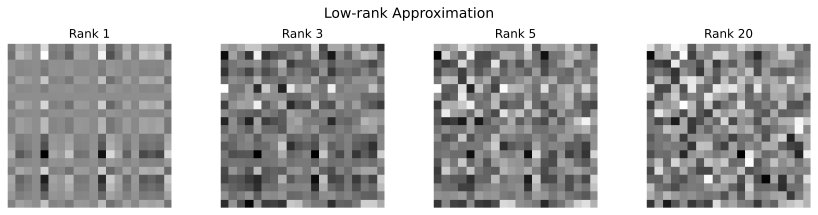

In [16]:
# Low-rank approximation menggunakan SVD
# Buat matriks gambar sederhana
np.random.seed(0)
img = np.random.randn(20, 20)

# SVD decomposition
U, S, Vt = np.linalg.svd(img)

# Rekonstruksi dengan rank berbeda
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

ranks = [1, 3, 5, 20]
for ax, r in zip(axes, ranks):
    # Low-rank approximation
    img_approx = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]
    ax.imshow(img_approx, cmap='gray')
    ax.set_title(f'Rank {r}')
    ax.axis('off')

plt.suptitle('Low-rank Approximation', fontsize=14)
plt.tight_layout()
plt.show()

## 5.10 Rank dan Nullity: Teorema Rank-Nullity

**Teorema Rank-Nullity** (juga disebut **dimensi theorem**) menyatakan:

```
rank(A) + nullity(A) = n
```

Di mana:
- n adalah jumlah kolom matriks A
- rank(A) adalah dimensi dari column space (atau row space)
- nullity(A) adalah dimensi dari null space (kernel) dari A

Null space dari A adalah himpunan semua vektor x sehingga Ax = 0.

In [17]:
# Demonstrasi teorema rank-nullity
A = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

m, n = A.shape
rank_A = np.linalg.matrix_rank(A)
nullity_A = n - rank_A

print(f'Matriks A berukuran {m} x {n}')
print(f'Rank(A) = {rank_A}')
print(f'Nullity(A) = n - rank = {n} - {rank_A} = {nullity_A}')
print(f'Verifikasi: rank + nullity = {rank_A} + {nullity_A} = {rank_A + nullity_A} (harus = n = {n})')

Matriks A berukuran 3 x 4
Rank(A) = 2
Nullity(A) = n - rank = 4 - 2 = 2
Verifikasi: rank + nullity = 2 + 2 = 4 (harus = n = 4)


## 5.11 Cara Komputasi Rank: Nilai Singular

Cara yang paling numerically stable untuk menghitung rank adalah melalui **Singular Value Decomposition (SVD)**. Rank matriks sama dengan jumlah singular value yang signifikan (non-nol secara numeris).

NumPy menggunakan pendekatan ini secara internal dalam fungsi `matrix_rank()`. Ada threshold toleransi yang digunakan untuk menentukan apakah singular value dianggap nol atau tidak, karena floating point arithmetic tidak pernah menghasilkan nol yang sempurna.

In [18]:
# Hitung rank menggunakan singular values
A_test = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=float)

U, S, Vt = np.linalg.svd(A_test)
print('Singular values:', np.round(S, 10))
print()

# Threshold untuk menentukan nilai 'nol'
tol = 1e-10
rank_from_svd = np.sum(S > tol)
print(f'Jumlah singular value > {tol}:', rank_from_svd)
print('Rank dari np.linalg.matrix_rank:', np.linalg.matrix_rank(A_test))

Singular values: [16.84810335  1.06836951  0.        ]

Jumlah singular value > 1e-10: 2
Rank dari np.linalg.matrix_rank: 2


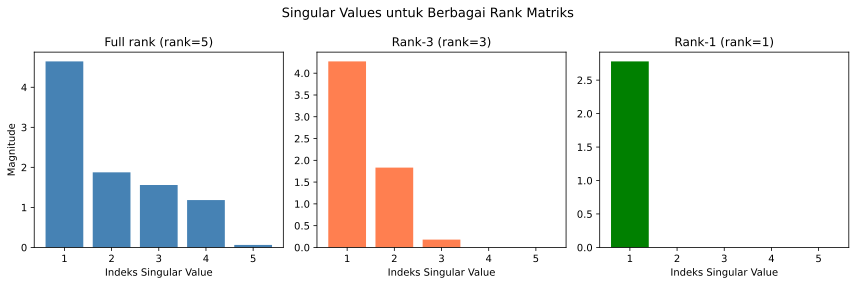

In [19]:
# Visualisasi singular values untuk berbagai matriks
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Matriks 1: rank penuh
np.random.seed(1)
M1 = np.random.randn(5, 5)
_, S1, _ = np.linalg.svd(M1)
axes[0].bar(range(1, len(S1)+1), S1, color='steelblue')
axes[0].set_title(f'Full rank (rank={np.linalg.matrix_rank(M1)})')
axes[0].set_xlabel('Indeks Singular Value')
axes[0].set_ylabel('Magnitude')

# Matriks 2: rank-3
M2 = np.random.randn(5, 3) @ np.random.randn(3, 5)
_, S2, _ = np.linalg.svd(M2)
axes[1].bar(range(1, len(S2)+1), S2, color='coral')
axes[1].set_title(f'Rank-3 (rank={np.linalg.matrix_rank(M2)})')
axes[1].set_xlabel('Indeks Singular Value')

# Matriks 3: rank-1
v = np.random.randn(5)
M3 = np.outer(v, v)
_, S3, _ = np.linalg.svd(M3)
axes[2].bar(range(1, len(S3)+1), S3, color='green')
axes[2].set_title(f'Rank-1 (rank={np.linalg.matrix_rank(M3)})')
axes[2].set_xlabel('Indeks Singular Value')

plt.suptitle('Singular Values untuk Berbagai Rank Matriks', fontsize=13)
plt.tight_layout()
plt.show()

## Ringkasan Bab 5

Pada bab ini kita telah mempelajari:

1. **Rank** adalah jumlah kolom (atau baris) linearly independent dalam sebuah matriks.
2. Rank selalu memenuhi: rank(A) <= min(m, n) untuk matriks m x n.
3. Matriks disebut **full rank** jika rank = min(m, n), dan **rank-deficient** jika kurang dari itu.
4. **RREF** memperlihatkan rank melalui jumlah pivot.
5. **Teorema Rank-Nullity**: rank(A) + nullity(A) = n.
6. Rank matriks persegi n x n yang full rank memiliki determinan tidak nol dan dapat diinvers.
7. SVD adalah metode paling stabil secara numeris untuk menghitung rank.
8. Dalam machine learning, rank sangat penting untuk regresi, PCA, dan low-rank approximation.